<a href="https://colab.research.google.com/github/gabrielqv-ai/Cofee_plagues_ai/blob/main/Analisis_Exploratorio_YoloV8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análisis Exploratorio de datos del proyecto

 **Presentado por:
Andrés Felipe Cuellar -  
Victor Gabriel Quijano Vidal**

Para realizar la exploración de los datos relacionados con fotografías de hojas de café, se usa el Dataset público denominado "BRACOL - Brazilian Arabica Coffee Leaf for Object Detection with YOLO architectures". Disponible en: https://doi.org/10.3390/app15095040



Iniciamos cargando el dataset mediante la instalación de Roboflow, aclarando que se utilizará YOLO v8 para este proyecto.

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="n6IOMI8AsOyqVfkdmOVc")
project = rf.workspace("jonatan-fragoso").project("bracol-validado")
version = project.version(3)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import os
import cv2  # OpenCV para procesamiento de imágenes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image  # Alternativa a CV2, útil para metadatos
from tqdm.notebook import tqdm  # Para barras de progreso
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Configuración de visualización
%matplotlib inline
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("Librerías importadas exitosamente.")

Librerías importadas exitosamente.


## Fase 1: Análisis de Metadatos y Estructura



Se inicia defininiendo las variables IMG_DIR y LABEL_DIR que apuntan a las carpetas de imágenes y etiquetas (anotaciones) dentro del dataset descargado. Finalizando este bloque se cuenta cuántos archivos .jpg (imágenes) y .txt (etiquetas) hay en estas carpetas.

In [ ]:
IMG_DIR = Path('BRACOL-VALIDADO-3/train/images')
LABEL_DIR = Path('BRACOL-VALIDADO-3/train/labels')
CLASS_NAMES = {0:'Cercospora', 1:'Miner', 2:'Phoma', 3: 'Roya'}

image_files = sorted([f.name for f in IMG_DIR.glob('*.jpg')]) # Ajustar extensión (.png, etc.)
label_files = sorted([f.name for f in LABEL_DIR.glob('*.txt')])

print(f"Total de imágenes encontradas: {len(image_files)}")
print(f"Total de etiquetas (labels) encontradas: {len(label_files)}")

Total de imágenes encontradas: 1213
Total de etiquetas (labels) encontradas: 1213


In [ ]:
# Verificar si hay imágenes sin etiqueta o viceversa
img_stems = set([Path(f).stem for f in image_files])
lbl_stems = set([Path(f).stem for f in label_files])

if img_stems == lbl_stems:
    print("\n¡Perfecto! Cada imagen tiene su archivo de etiqueta correspondiente.")
else:
    print(f"\n¡Atención! Hay discrepancias:")
    print(f"Imágenes sin etiqueta: {img_stems - lbl_stems}")
    print(f"Etiquetas sin imagen: {lbl_stems - img_stems}")


¡Perfecto! Cada imagen tiene su archivo de etiqueta correspondiente.


Esta primera validación indica que se tiene el mismo número de imágenes que de archivos de etiquetas, lo que sugiere que el dataset está completo.

##Distribución de Clases (Balanceo)

A continuación, se extrae los nombres de archivo base (sin la extensión .jpg o .txt). Para comparar los dos conjuntos de nombres para asegurarse de que cada imagen tiene su etiqueta correspondiente por nombre.

En este bloque se tienen varias tareas, iniciando con Descubrimiento: Iterando sobre todos los archivos .txt para encontrar los nombres de clase únicos que usaste en tus anotaciones (ej. '0', '1', '2', '3').

Mapeo: Crea un diccionario CLASS_NAMES que mapea esos nombres de texto a un ID numérico (ej. 0: '0', 1: '1', etc.).

Conteo: Vuelve a iterar sobre todos los archivos. Esta vez, lee cada línea (cada bounding box), identifica su clase, y suma 1 al conteo de esa clase. También almacena todas las coordenadas de los bounding boxes en un DataFrame de pandas (df_bbox) para usarlo más adelante.

Visualización: Usa seaborn.barplot para crear un gráfico de barras que muestra el número total de instancias (objetos) para cada clase.

Fase 1: Descubriendo nombres de clases únicas...


  0%|          | 0/1213 [00:00<?, ?it/s]


Clases descubiertas en los archivos .txt: {'3', '0', '1', '2'}

Mapa de Clases Creado (ID -> Nombre):
{0: '0', 1: '1', 2: '2', 3: '3'}

Fase 2: Contando instancias por clase...


  0%|          | 0/1213 [00:00<?, ?it/s]


Conteo total de instancias (objetos) por clase:
{0: 133, 1: 171, 2: 1310, 3: 4184}

Generando gráfico de distribución de clases...


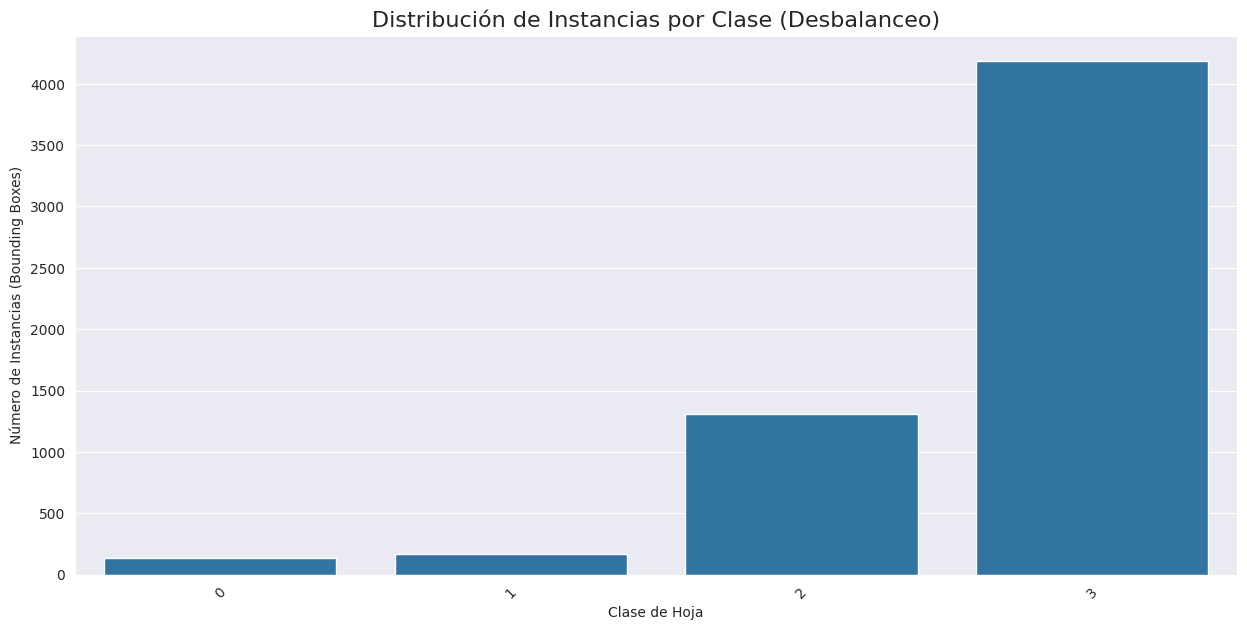


Número de *imágenes* que contienen al menos una instancia de la clase:
{'0': 86, '1': 107, '2': 613, '3': 453}


In [ ]:

# Encontrar todas las clases únicas
print("Fase 1: Descubriendo nombres de clases únicas...")
discovered_class_names = set()

# Iteramos por todos los archivos de etiquetas
for lbl_file in tqdm(label_files):
    try:
        with open(LABEL_DIR / lbl_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                if line.strip(): # Asegurarse que la línea no esté vacía
                    class_name = line.strip().split()[0]
                    discovered_class_names.add(class_name)
    except Exception as e:
        print(f"Advertencia: No se pudo leer {lbl_file}: {e}")

print(f"\nClases descubiertas en los archivos .txt: {discovered_class_names}")

# FASE DE MAPEO: Crear los diccionarios de conversión
# Ordenamos los nombres para tener un orden consistente (ej. alfabético)
sorted_names = sorted(list(discovered_class_names))

# Creamos el mapa de Nombre -> ID (ej: {'Phoma': 0, 'sana': 1})
NAME_TO_ID = {name: i for i, name in enumerate(sorted_names)}

# Creamos el mapa de ID -> Nombre (ej: {0: 'Phoma', 1: 'sana'})
# ESTE REEMPLAZA AL QUE DEFINIMOS MANUALMENTE EN LA CELDA 2
CLASS_NAMES = {i: name for i, name in enumerate(sorted_names)}

print("\nMapa de Clases Creado (ID -> Nombre):")
print(CLASS_NAMES)

# FASE DE CONTEO (Ahora sí, usando el mapa)
print("\nFase 2: Contando instancias por clase...")

# Inicializar contadores AHORA que sabemos las clases
class_counts = {k: 0 for k in CLASS_NAMES.keys()}
images_per_class = {k: set() for k in CLASS_NAMES.keys()}
bbox_data = []

for lbl_file in tqdm(label_files):
    try:
        with open(LABEL_DIR / lbl_file, 'r') as f:
            lines = f.readlines()
            if not lines:
                continue

            for line in lines:
                if not line.strip():
                    continue

                parts = line.strip().split()

                # --- LA MODIFICACIÓN CLAVE ---
                class_name = parts[0] # Ej: 'Phoma'
                class_id = NAME_TO_ID[class_name] # Convertir a ID numérico, ej: 0
                # -----------------------------

                class_counts[class_id] += 1
                images_per_class[class_id].add(lbl_file)

                # Guardar info de BBox para Fase 4
                bbox_data.append({
                    'filename': lbl_file,
                    'class_id': class_id,
                    'x_center': float(parts[1]),
                    'y_center': float(parts[2]),
                    'width': float(parts[3]),
                    'height': float(parts[4])
                })

    except Exception as e:
        print(f"Error procesando línea en {lbl_file}: {e}")

# Convertir a DataFrame para análisis más fácil
df_bbox = pd.DataFrame(bbox_data)

print("\nConteo total de instancias (objetos) por clase:")
print(class_counts)


# --- CÓDIGO DE VISUALIZACIÓN (antes celda 3.3) ---
# Lo ponemos aquí mismo ya que tenemos los datos listos

print("\nGenerando gráfico de distribución de clases...")
class_names_list = [CLASS_NAMES[k] for k in class_counts.keys()]
instance_counts = list(class_counts.values())

plt.figure(figsize=(15, 7))
sns.barplot(x=class_names_list, y=instance_counts)
plt.title('Distribución de Instancias por Clase (Desbalanceo)', fontsize=16)
plt.xlabel('Clase de Hoja')
plt.ylabel('Número de Instancias (Bounding Boxes)')
plt.xticks(rotation=45) # Añadido por si los nombres son largos
plt.show()

# También es útil ver cuántas *imágenes* contienen cada clase
img_counts = {CLASS_NAMES[k]: len(v) for k, v in images_per_class.items()}
print("\nNúmero de *imágenes* que contienen al menos una instancia de la clase:")
print(img_counts)

# --- FIN DEL NUEVO CÓDIGO ---

El proceso de análisis de distribución de las clases muestra que los archivos de etiquetas usan estos cuatro identificadores.

Mapa de Clases: {0: '0', 1: '1', 2: '2', 3: '3'}.

Conteo de Instancias: {0: 133, 1: 171, 2: 1310, 3: 4184}. Indicando que dentro de las imagenes que componen el dataset, se detectaron más objetos de las clases 2 y 3.


El gráfico de barras es el hallazgo más crítico. Muestra un fuerte desbalanceo de clases.
La Clase '3' (Roya) domina el dataset con 4184 instancias.
La Clase '2' (Phoma) es la segunda más común con 1310 instancias.
Las Clases '0' (Cercospora) y '1' (Miner) están muy subrepresentadas, con solo 133 y 171 instancias respectivamente.

Conclusión: Con los datos actuales, el modelo de detección aprenderá muy bien a detectar 'Roya', pero tendrá muchas dificultades para identificar 'Cercospora' y 'Miner'.

Conteo de Imágenes por Clase: {'0': 86, '1': 107, '2': 613, '3': 453}.

Este es un dato muy interesante. Aunque 'Roya' (clase 3) tiene la mayor cantidad de instancias (4184), solo aparece en 453 imágenes. En cambio, 'Phoma' (clase 2) aparece en 613 imágenes.

Interpretación: Esto nos dice que las imágenes de 'Roya' tienen muchas instancias por imagen (ej. 4184 / 453 ≈ 9.2 instancias por imagen), mientras que 'Phoma' tiene menos (1310 / 613 ≈ 2.1 instancias por imagen). Esto tiene sentido: la roya suelen ser muchas manchas pequeñas, mientras que Phoma puede ser una lesión más grande.

## Fase 2: Propiedades Visuales y Calidad

Analicemos las propiedades de las imágenes: tamaño, relación de aspecto y calidad visual.

In [ ]:
image_data = []
print("Analizando metadatos de imágenes...")

for img_file in tqdm(image_files):
    try:
        with Image.open(IMG_DIR / img_file) as img:
            image_data.append({
                'filename': img_file,
                'width': img.width,
                'height': img.height,
                'aspect_ratio': img.width / img.height,
                'mode': img.mode # RGB, RGBA, L (escala de grises)
            })
    except Exception as e:
        print(f"No se pudo leer {img_file}: {e}")

df_img = pd.DataFrame(image_data)

print("\nResumen de propiedades de imagen:")
print(df_img.describe())

print("\nConteo de Modos de Color (esperamos 'RGB'):")
print(df_img['mode'].value_counts())

Analizando metadatos de imágenes...


  0%|          | 0/1213 [00:00<?, ?it/s]


Resumen de propiedades de imagen:
        width  height  aspect_ratio
count  1213.0  1213.0        1213.0
mean   2048.0  1024.0           2.0
std       0.0     0.0           0.0
min    2048.0  1024.0           2.0
25%    2048.0  1024.0           2.0
50%    2048.0  1024.0           2.0
75%    2048.0  1024.0           2.0
max    2048.0  1024.0           2.0

Conteo de Modos de Color (esperamos 'RGB'):
mode
RGB    1213
Name: count, dtype: int64


Se encuentra que todas las 1213 imágenes tienen exactamente el mismo tamaño (2048x1024). Esto es excelente y simplifica mucho el pre-procesamiento. No será necesario redimensionar o añadir padding (relleno) a las imágenes antes de entrenar.

Modos de Color: RGB 1213. Esto confirma que todas las imágenes son a color (3 canales) y no hay ninguna en escala de grises.

Visualización de Dimensiones

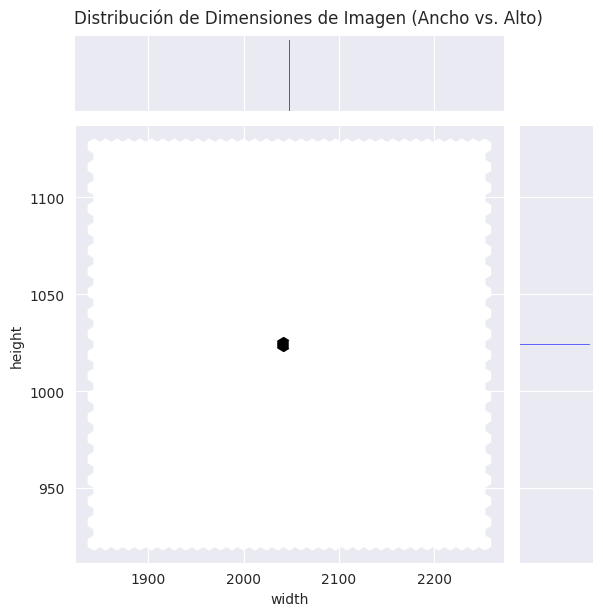

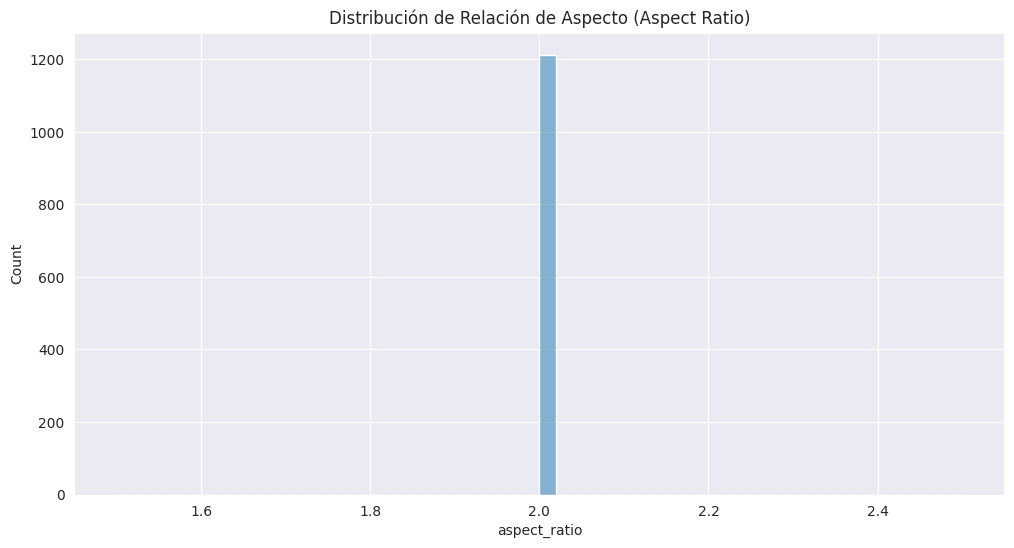

In [ ]:
# Gráfico de dispersión de Ancho vs. Alto
sns.jointplot(data=df_img, x='width', y='height', kind='hex', color='blue')
plt.suptitle('Distribución de Dimensiones de Imagen (Ancho vs. Alto)', y=1.02)
plt.show()

# Histograma de Relación de Aspecto
plt.figure(figsize=(12, 6))
sns.histplot(df_img['aspect_ratio'], bins=50, kde=True)
plt.title('Distribución de Relación de Aspecto (Aspect Ratio)')
plt.show()

Se crearon las dos representaciones gráficas a través de Seaborn para verificar las dimensiones de las imagenes. El gráfico muestra un solo hexágono oscuro en la coordenada (2048, 1024). Esto confirma visualmente que todas las imágenes están en un solo clúster de tamaño. El Histograma de Relación de Aspecto muestra una sola barra muy alta en el valor 2.0. Esto también confirma que todas las imágenes tienen la misma relación de aspecto (2048 / 1024 = 2).

##Inspección Visual de Calidad (Muestreo)

Creemos una función para ver imágenes aleatorias y sus etiquetas.

Mostrando muestra aleatoria general...


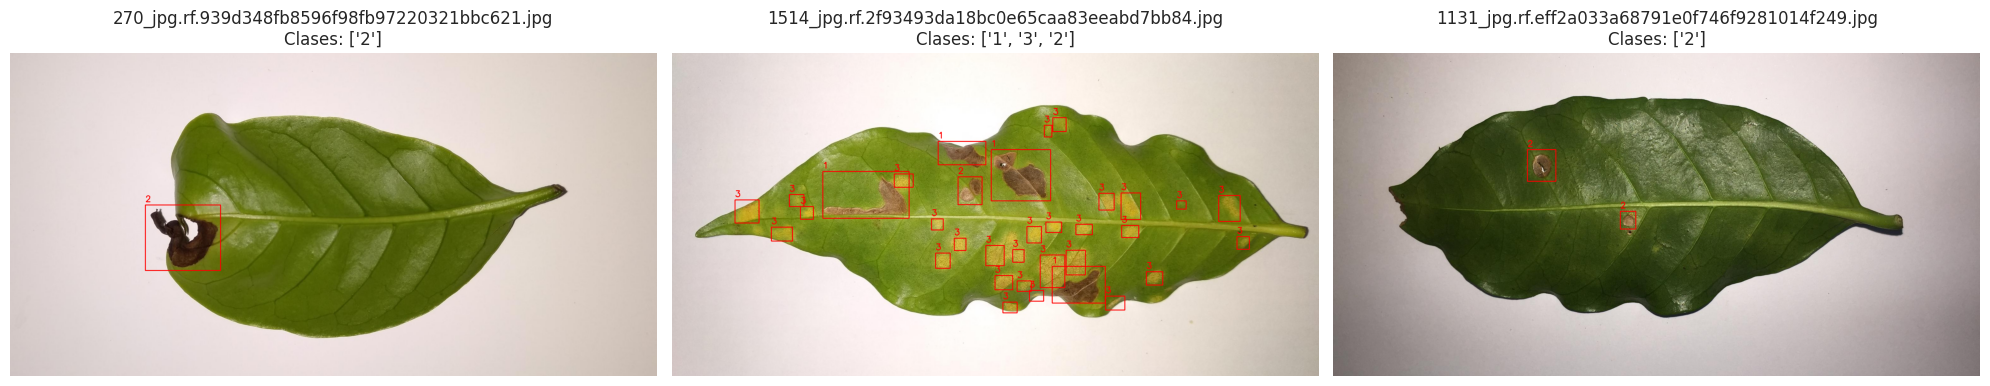


Mostrando muestra de la clase 'enferma_tipo_A' (ID 1)...


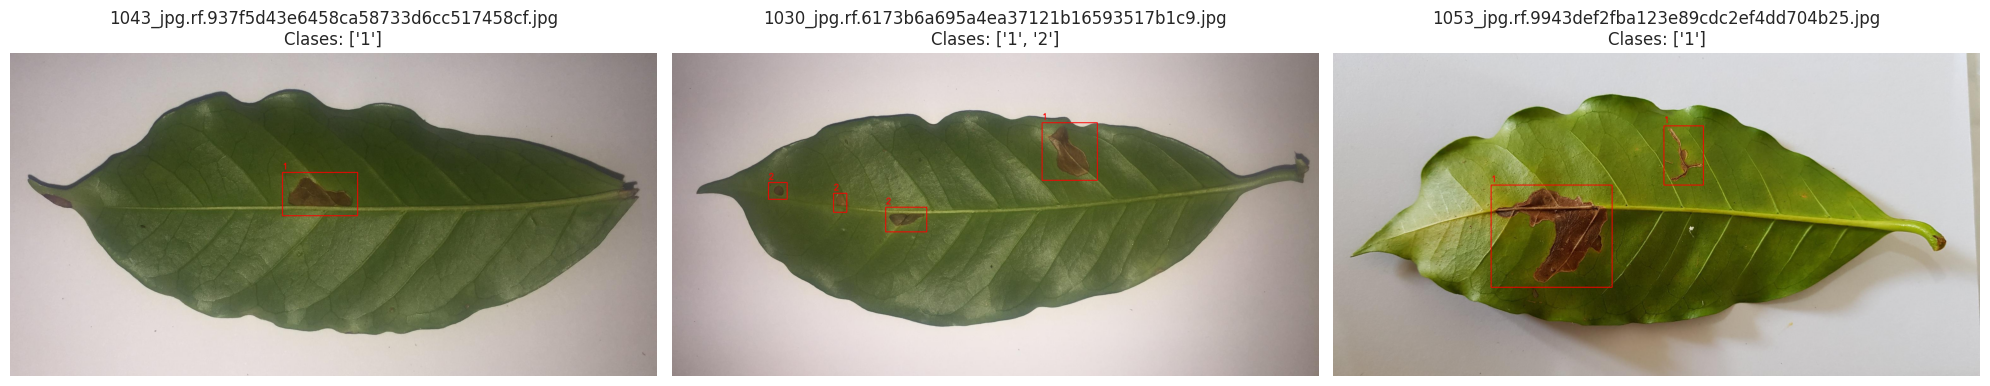

In [ ]:
def show_random_images_with_boxes(n_images=5, class_id=None):
    """
    Muestra n imágenes aleatorias con sus bounding boxes.
    Si se especifica class_id, filtra por imágenes que contengan esa clase.
    """

    target_files = df_bbox['filename'].unique()
    if class_id is not None:
        target_files = df_bbox[df_bbox['class_id'] == class_id]['filename'].unique()
        if len(target_files) == 0:
            print(f"No se encontraron imágenes para la clase {CLASS_NAMES[class_id]}")
            return

    chosen_files = np.random.choice(target_files, min(n_images, len(target_files)), replace=False)

    plt.figure(figsize=(20, n_images * 5))

    for i, lbl_filename in enumerate(chosen_files):
        img_filename = Path(lbl_filename).stem + '.jpg' # Ajustar extensión
        img_path = IMG_DIR / img_filename

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        # Cargar BBoxes
        bboxes = df_bbox[df_bbox['filename'] == lbl_filename]

        for _, row in bboxes.iterrows():
            # Convertir formato YOLO (relativo) a CV2 (absoluto)
            x_c, y_c, w_rel, h_rel = row['x_center'], row['y_center'], row['width'], row['height']
            x1 = int((x_c - w_rel / 2) * w)
            y1 = int((y_c - h_rel / 2) * h)
            x2 = int((x_c + w_rel / 2) * w)
            y2 = int((y_c + h_rel / 2) * h)

            class_name = CLASS_NAMES[row['class_id']]
            color = (255, 0, 0) # Rojo para BBox (puedes asignar colores por clase)

            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        plt.subplot(1, n_images, i + 1)
        plt.imshow(img)
        plt.title(f"{img_filename}\nClases: {[CLASS_NAMES[cid] for cid in bboxes['class_id'].unique()]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Muestreo general
print("Mostrando muestra aleatoria general...")
show_random_images_with_boxes(n_images=3)

# Muestreo de una clase específica (ej. clase 1: 'roya')
print("\nMostrando muestra de la clase 'enferma_tipo_A' (ID 1)...")
show_random_images_with_boxes(n_images=3, class_id=1)

Este bloque genera una muestra aleatoria de las imágenes, delimitando en rectángulos algunas de las lesiones con su respectiva etiqueta, al parecer muestra con buena precisión las diferentes enfermedades dentrto de su recuadro delimitador.

##Fase 3: Análisis de Contenido y Píxeles

Vamos a analizar los píxeles dentro de los bounding boxes para entender las características de color de cada clase. Calcularemos el histograma de color promedio (en espacio HSV, que es mejor para separar color de iluminación) para los píxeles dentro de las cajas.

Calculando histogramas de color (Hue) por clase. Esto puede tardar...


  0%|          | 0/5798 [00:00<?, ?it/s]

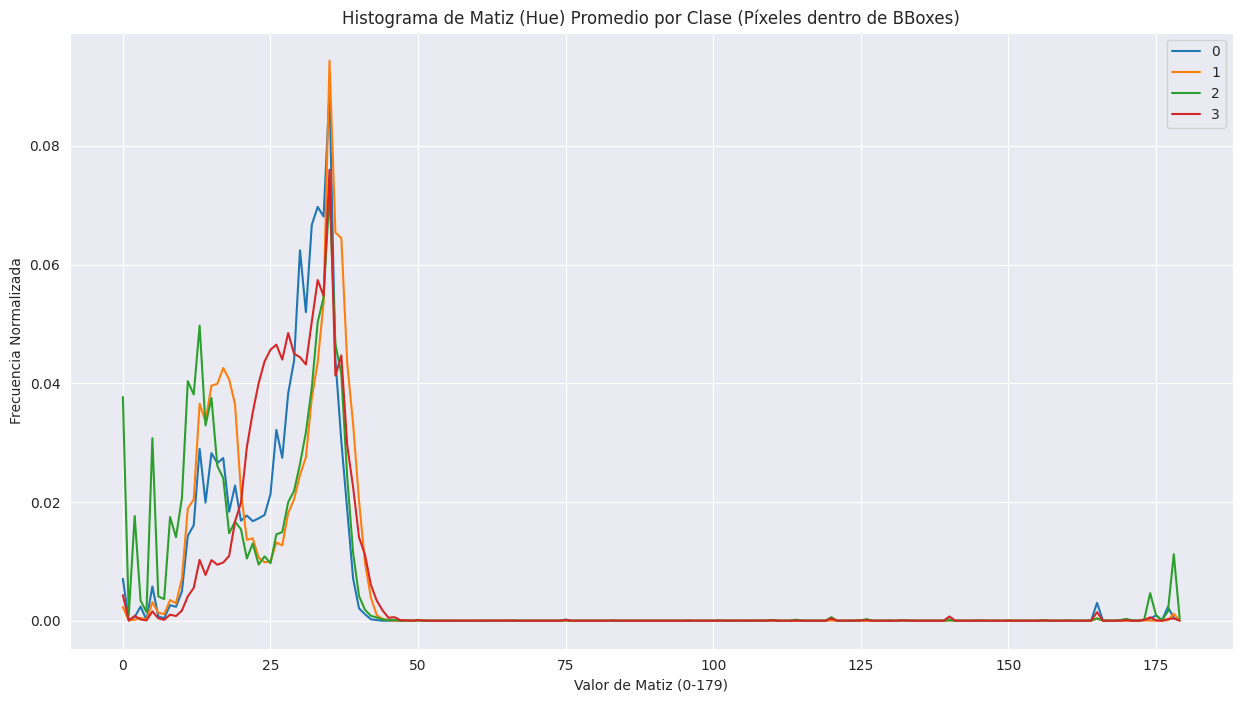

In [ ]:
# Esta celda puede tardar un poco
# Almacenará los histogramas promedio
class_hsv_hist = {k: np.zeros(180) for k in CLASS_NAMES.keys()} # Histograma de Hue (Matiz)
class_pixel_counts = {k: 0 for k in CLASS_NAMES.keys()}

print("Calculando histogramas de color (Hue) por clase. Esto puede tardar...")

for index, row in tqdm(df_bbox.iterrows(), total=df_bbox.shape[0]):
    try:
        img_filename = Path(row['filename']).stem + '.jpg' # Ajustar extensión
        img_path = IMG_DIR / img_filename

        img = cv2.imread(str(img_path))
        h, w, _ = img.shape

        # Obtener coordenadas absolutas del BBox
        x_c, y_c, w_rel, h_rel = row['x_center'], row['y_center'], row['width'], row['height']
        x1 = int((x_c - w_rel / 2) * w)
        y1 = int((y_c - h_rel / 2) * h)
        x2 = int((x_c + w_rel / 2) * w)
        y2 = int((y_c + h_rel / 2) * h)

        # Recortar la región de interés (ROI)
        roi = img[y1:y2, x1:x2]
        if roi.size == 0:
            continue

        # Convertir a HSV
        roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

        # Calcular histograma de Hue (Matiz, canal 0)
        # Rango 0-179 en OpenCV
        hist = cv2.calcHist([roi_hsv], [0], None, [180], [0, 180])

        # Acumular histogramas
        class_id = row['class_id']
        class_hsv_hist[class_id] += hist.flatten()
        class_pixel_counts[class_id] += roi_hsv.shape[0] * roi_hsv.shape[1]

    except Exception as e:
        # print(f"Error procesando {img_filename} para hist: {e}")
        pass # Omitir errores de lectura o recorte

# Normalizar los histogramas
plt.figure(figsize=(15, 8))
for class_id, hist in class_hsv_hist.items():
    if class_pixel_counts[class_id] > 0:
        normalized_hist = hist / class_pixel_counts[class_id]
        plt.plot(normalized_hist, label=CLASS_NAMES[class_id])

plt.title('Histograma de Matiz (Hue) Promedio por Clase (Píxeles dentro de BBoxes)')
plt.xlabel('Valor de Matiz (0-179)')
plt.ylabel('Frecuencia Normalizada')
plt.legend()
plt.show()

Clase 0 (Cercospora) - Curva Azul
Picos: Esta es la clase más compleja. No tiene un solo pico dominante. Muestra múltiples picos pequeños y una distribución más amplia, con picos notables alrededor de 15-25 (naranja/marrón) y 30-40 (verde-amarillento). La falta de un pico claro sugiere que 'Cercospora' puede tener una apariencia visual más variable. Puede presentarse con colores similares a la 'Roya' (pico en 15-25) y también con colores similares al 'Miner' (pico en 30-40).

Clase 1 (Miner) - Curva Roja
Pico Principal: Esta clase muestra un pico claro alrededor del rango 30-40 del eje X. Este rango corresponde a tonos verdes-amarillentos. Esto sugiere que el daño por 'Miner' (Minador) no se manifiesta como un color de "enfermedad" (marrón/naranja), sino más bien como un verde pálido o amarillento, posiblemente por la pérdida de clorofila donde la larva ha comido.

Clase 2 (Phoma) - Curva Naranja
Pico Principal: Esta clase tiene el pico más dominante y definido de todas, centrado aproximadamente en el rango 20-30 del eje X.  Este rango (20-30) en el espacio HSV corresponde a tonos amarillos y naranjas claros. Esto sugiere fuertemente que las lesiones de 'Phoma' en tu dataset tienen un color amarillo/naranja muy consistente y distintivo. Es una firma de color muy fuerte.

Clase 3 (Roya) - Curva Verde
Pico Principal: Esta clase tiene un pico muy claro centrado alrededor de 15-25 en el eje X. Este rango (15-25) corresponde a tonos naranjas y marrones claros.
Las lesiones de 'Roya' también tienen una firma de color naranja/marrón muy clara, lo cual es esperado para esta enfermedad.



##Fase 4: Análisis Específico para Detección (YOLO)

Revisamos la distribución de Tamaños de Bounding Box, Usamos el df_bbox que creamos en la Fase 1. Analizamos el ancho (width) y alto (height) relativos.

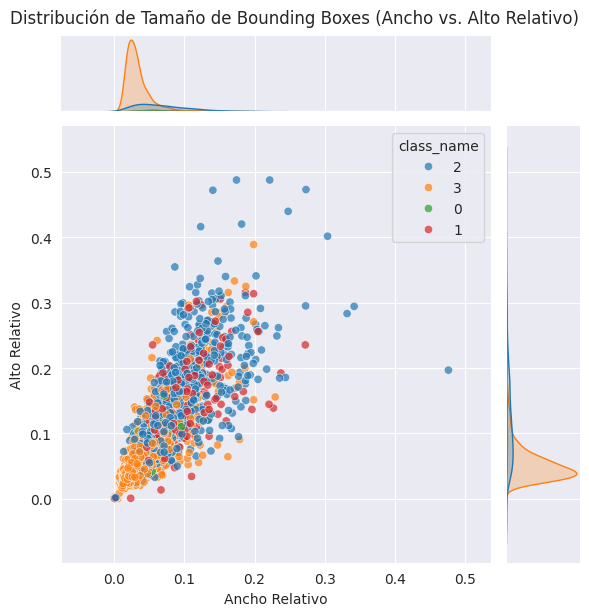

In [ ]:
# Añadir nombre de clase al DataFrame para mejores gráficos
df_bbox['class_name'] = df_bbox['class_id'].map(CLASS_NAMES)

# Gráfico de dispersión de Ancho vs. Alto de los BBoxes
# 'width' y 'height' están en formato relativo (0 a 1)
sns.jointplot(data=df_bbox, x='width', y='height', hue='class_name', alpha=0.7)
plt.suptitle('Distribución de Tamaño de Bounding Boxes (Ancho vs. Alto Relativo)', y=1.02)
plt.xlabel('Ancho Relativo')
plt.ylabel('Alto Relativo')
plt.show()

Se encontró que la gran mayoría de los bounding boxes (lesiones) tienen un ancho relativo y un alto relativo muy pequeños. Casi todos los objetos ocupan menos del 20% del ancho (< 0.2) y menos del 20% del alto (< 0.2) de la imagen. En pocas palabras, el proyecto trata un problema de detección de objetos pequeños.

Heatmap de Posición de Bounding Box
¿Dónde suelen aparecer las hojas o enfermedades en la imagen?

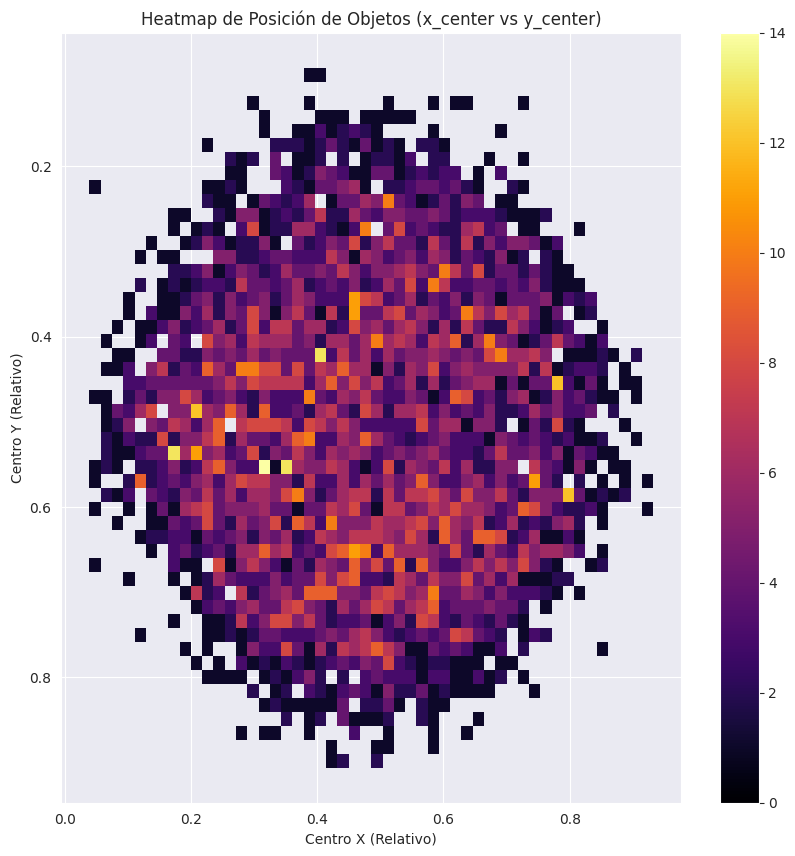

In [ ]:
# Heatmap de x_center vs y_center
plt.figure(figsize=(10, 10))
sns.histplot(data=df_bbox, x='x_center', y='y_center', bins=50, cbar=True, cmap='inferno')
plt.title('Heatmap de Posición de Objetos (x_center vs y_center)')
plt.xlabel('Centro X (Relativo)')
plt.ylabel('Centro Y (Relativo)')
plt.gca().invert_yaxis() # Poner (0,0) en la esquina superior izquierda
plt.show()

La interpretación del mapa de calor nos lleva a concluir que la gran mayoría de los objetos están ubicados en el centro de la imagen.

El punto amarillo brillante, que representa la mayor concentración (más de 2000 instancias), está justo en el medio, alrededor de X=0.5 y Y=0.5. La concentración disminuye drásticamente a medida que nos alejamos del centro hacia los bordes.

Esto es un signo de un buen proceso de recolección de datos. Significa que las personas que tomaron las 1,700 fotos hicieron un buen trabajo centrando la hoja o la lesión de interés.

Sin embargo, según encontramos en literatura de proyectos similares, el modelo puede aprender un "atajo". es decir, existe el riesgo de que el modelo desarrolle un sesgo de posición.

El modelo podría volverse "perezoso" y aprender una regla simple como: "Si algo está en el centro de la imagen, es probable que sea una lesión. Si está en una esquina, probablemente no lo sea". Esto es un problema, porque si luego usas el modelo en una foto nueva donde la lesión está en un borde, el modelo podría fallar en detectarla.Lo que nos llevará en proximas fases del proyecto a buscar alternativas para evitar dicho sesgo.